In [1]:
import geopandas as gpd
from geopandas import datasets
from shapely.geometry import Point
import pandas as pd
from shapely.ops import unary_union
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

In [2]:
# Load Alaska and Canadian provinces
states = gpd.read_file("ne_50m_admin_1_states_provinces.shp")

region = states[states['name'].isin(['Alaska', 'Yukon', 'Northwest Territories', 'British Columbia'])]

# Data source: Natural Earth, States and Provinces (downloaded from https://www.naturalearthdata.com/downloads/50m-cultural-vectors/)

In [3]:
# Load river basin shapefile for the Arctic
hb = gpd.read_file("hybas_ar_lev03_v1c.shp")
print(hb.columns)

# Data source: HydroBASINS, Standard, Arctic, Level 3 (downloaded from https://www.hydrosheds.org/products/hydrobasins)
# Citation: Lehner, B., Grill G. (2013). Global river hydrography and network routing: baseline data and new approaches to study the world’s large river systems. Hydrological Processes, 27(15): 2171–2186. https://doi.org/10.1002/hyp.9740

Index(['HYBAS_ID', 'NEXT_DOWN', 'NEXT_SINK', 'MAIN_BAS', 'DIST_SINK',
       'DIST_MAIN', 'SUB_AREA', 'UP_AREA', 'PFAF_ID', 'ENDO', 'COAST', 'ORDER',
       'SORT', 'geometry'],
      dtype='object')


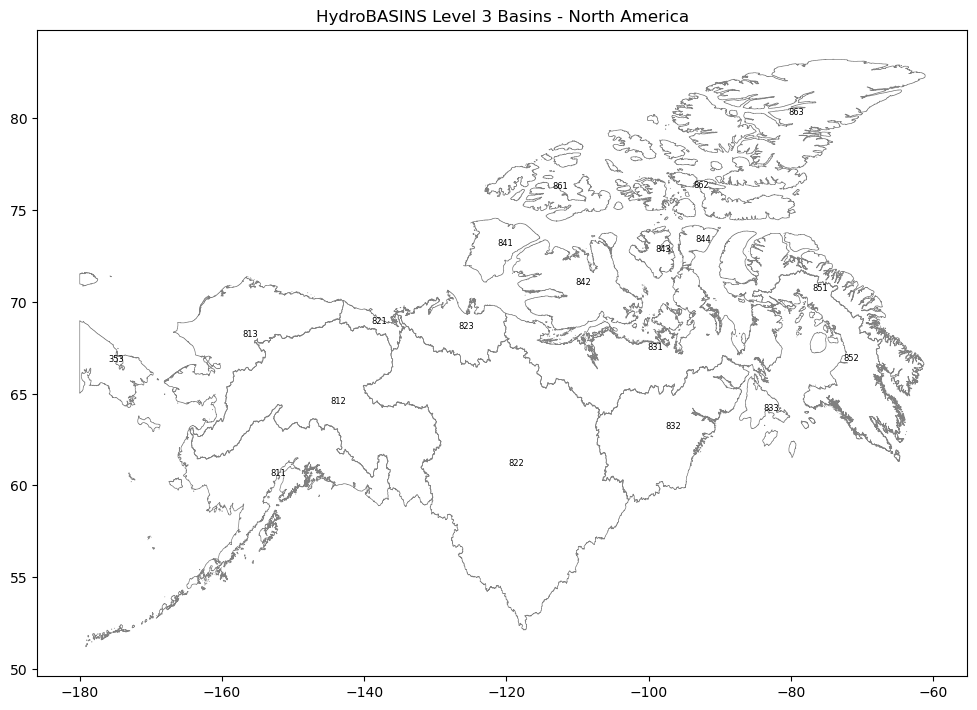

In [4]:
# Plot all basins to find the Yukon index
fig, ax = plt.subplots(figsize=(12, 10))
hb.boundary.plot(ax=ax, linewidth=0.5, edgecolor='gray')

# Add labels 
for idx, row in hb.iterrows():
    centroid = row.geometry.centroid
    ax.text(centroid.x, centroid.y, str(row['PFAF_ID']), fontsize=6)

ax.set_title("HydroBASINS Level 3 Basins - North America")
plt.show()

In [5]:
# Rough bounding box for Yukon River Basin (in degrees)
yukon = hb[hb['PFAF_ID'] == 812]

In [6]:
# List of coordinates (lon, lat)
locations = [
    {'name': 'Tanana', 'lon': -152.078, 'lat': 65.171},
    {'name': 'Fort Yukon', 'lon': -145.25, 'lat': 66.56},
    {'name': 'Eagle', 'lon': -141.199917, 'lat': 64.786022},
    {'name': 'Galena', 'lon': -156.885462, 'lat': 64.740643},
]

# Create DataFrame
df = pd.DataFrame(locations)

# Convert to GeoDataFrame with Point geometry
points = gpd.GeoDataFrame(
    df,
    geometry=gpd.points_from_xy(df.lon, df.lat),
    crs="EPSG:4326"  # input coords are in lat/lon
)

In [7]:
# Keep everything in EPSG:4326 (lat/lon)
region = region.to_crs("EPSG:4326")
yukon = yukon.to_crs("EPSG:4326")
points = points.to_crs("EPSG:4326")

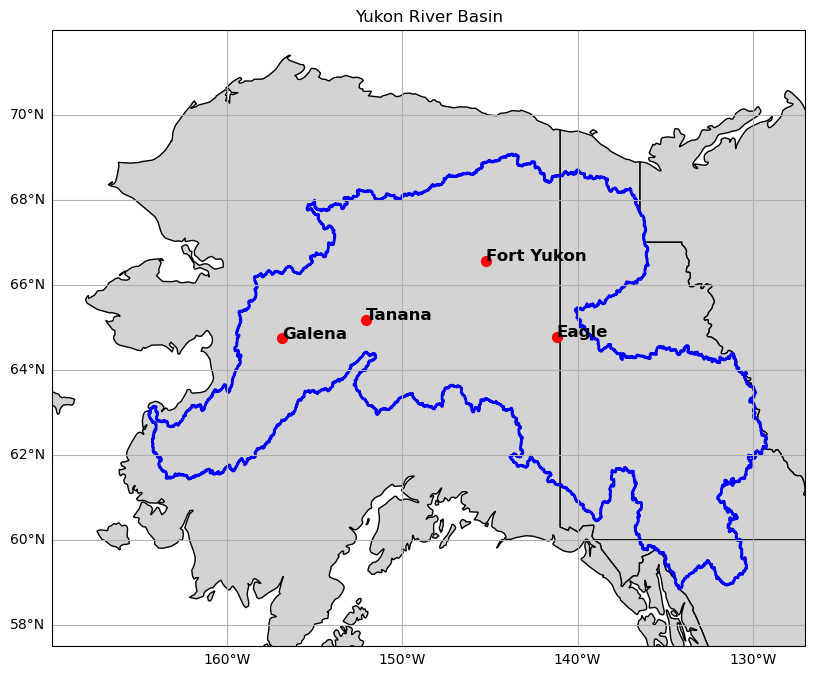

In [12]:
# Use PlateCarree for both map and transform
proj = ccrs.PlateCarree()

fig, ax = plt.subplots(figsize=(10, 8), subplot_kw={'projection': proj})

# Plot all data 
region.plot(ax=ax, facecolor='lightgray', edgecolor='black', transform=proj)
yukon.boundary.plot(ax=ax, color='blue', linewidth=2, transform=proj)
points.plot(ax=ax, color='red', markersize=50, transform=proj)

# Add labels
for lon, lat, label in zip(points.lon, points.lat, points['name']):
    ax.text(lon, lat, label, transform=proj, fontsize=12, fontweight='bold')

# Set map extent
ax.set_extent([-170, -127, 57.5, 72], crs=proj)

# Add lat/lon grid
gl = ax.gridlines(draw_labels=True, x_inline=False, y_inline=False)
gl.top_labels = False
gl.right_labels = False

plt.title("Yukon River Basin")

plt.savefig("Yukon_basin_map.pdf", bbox_inches="tight")
plt.show()